In [176]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


# UVA Breakdown

In [206]:
uva_data = df[df['Institution Name'] == 'University of Virginia'].copy()
uva_data

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd
...,...,...,...,...,...,...,...,...,...,...
26328,26329,374500,University of Virginia,Charlottesville,VA,43602,99885,Contract,SWEDEN,AutoLiv Development AB
26329,26330,374500,University of Virginia,Charlottesville,VA,43697,1000000,Monetary Gift,SWITZERLAND,Lawrence D & Karin S Howell
26330,26331,374500,University of Virginia,Charlottesville,VA,43796,500000,Monetary Gift,GUERNSEY,Harvest Group Holding (PTC Limited)
26331,26332,374500,University of Virginia,Charlottesville,VA,43803,146810,Contract,THE NETHERLANDS,Pantarhei Oncology BV


In [210]:
uva_gifts = (uva_data.groupby('Country of Giftor')['Foreign Gift Amount']
                     .count()
                     .nlargest(5)
                     .reset_index()
)

uva_gifts

,Country of Giftor,Foreign Gift Amount
0,ENGLAND,31
1,ISRAEL,12
2,BANGLADESH,10
3,SWEDEN,10
4,FINLAND,7


In [211]:
uva_totals = (uva_data.groupby('Country of Giftor')['Foreign Gift Amount']
                     .sum()
                     .nlargest(5)
                     .reset_index()
)

uva_totals

,Country of Giftor,Foreign Gift Amount
0,BANGLADESH,4228589
1,SWEDEN,4007552
2,TANZANIA,2776447
3,SWITZERLAND,2000000
4,ENGLAND,1950666


In [218]:
uva_donors = (uva_data.groupby(['Giftor Name', 'Country of Giftor'])['Foreign Gift Amount']
                     .sum()
                     .nlargest(5)
                     .reset_index()
)

uva_donors

,Giftor Name,Country of Giftor,Foreign Gift Amount
0,AstraZeneca,SWEDEN,3208048
1,Intrnl Centre Diarrheal Disease,BANGLADESH,1382896
2,Haydom Lutheran Hospital d/b/a Hayd,TANZANIA,1100553
3,Haydom Luther Hospital,TANZANIA,1035339
4,Harvest Group Holding,GUERNSEY,1000000


In [ ]:
ct = pd.crosstab(df['Institution Name'], df['Country of Giftor'],
            values=df['Foreign Gift Amount'], aggfunc='sum')


# Countries which give more to UVA than any other university

uva_top_countries = [
    country for country in ct if ct[country].idxmax() == 'University of Virginia'
]

uva_top_countries

['BANGLADESH']

UVA receives most gifts from England, but receives the largest amount from Bangladesh. Specifically, **icddr,b** from Bangladesh has given `$1.38M` to UVA. Bangladesh is the only country which gives more to UVA than any other school. **AstraZeneca** is also a top donor.

# Comparison with Similar Public Universities

In [177]:
college_list = {
    'University of Virginia' : 'virginia',
    'Virginia Polytechnic Institute & State University' : 'virginia tech',
    'West Virginia University' : 'west virginia',
    'University of North Carolina - Chapel Hill' : 'north carolina',
    'University of Maryland, College Park' : 'maryland',
    'University of Florida' : 'florida',
    'Georgia Institute of Technology' : 'georgia tech',
    'University of Georgia' : 'georgia'
}

In [178]:
college_data = df[df['Institution Name'].isin(college_list)].copy()
college_data['College Name'] = college_data['Institution Name'].map(college_list)
college_data

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name,College Name
11247,11248,153500,University of Florida,Gainesville,FL,43153,343790,Contract,SWITZERLAND,DSM Nutritional Products AG,florida
11248,11249,153500,University of Florida,Gainesville,FL,43167,1693595,Contract,JAPAN,GLOBAL HEALTH INNOVATIVE TECHNOLOGY,florida
11249,11250,153500,University of Florida,Gainesville,FL,43172,347586,Contract,THE NETHERLANDS,RIJK ZWAAN ZAADTEELT EN ZAADHANDEL,florida
11250,11251,153500,University of Florida,Gainesville,FL,43313,274827,Contract,SOUTH KOREA,Korea Sports Promotion Foundation,florida
11251,11252,153500,University of Florida,Gainesville,FL,43369,762500,Contract,IRELAND,United Neuroscience Limited,florida
...,...,...,...,...,...,...,...,...,...,...,...
26802,26803,382700,West Virginia University,Morgantown,WV,43815,926099,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia
26803,26804,382700,West Virginia University,Morgantown,WV,43815,951868,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia
26804,26805,382700,West Virginia University,Morgantown,WV,43815,313475,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia
26805,26806,382700,West Virginia University,Morgantown,WV,43819,492425,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia


In [179]:
gift_counts = college_data.groupby('College Name')['Foreign Gift Amount'].count().reset_index()
gift_counts

,College Name,Foreign Gift Amount
0,florida,33
1,georgia,124
2,georgia tech,203
3,maryland,86
4,north carolina,286
5,virginia,98
6,virginia tech,24
7,west virginia,33


UVA is 4th in total gifts received among in this group.

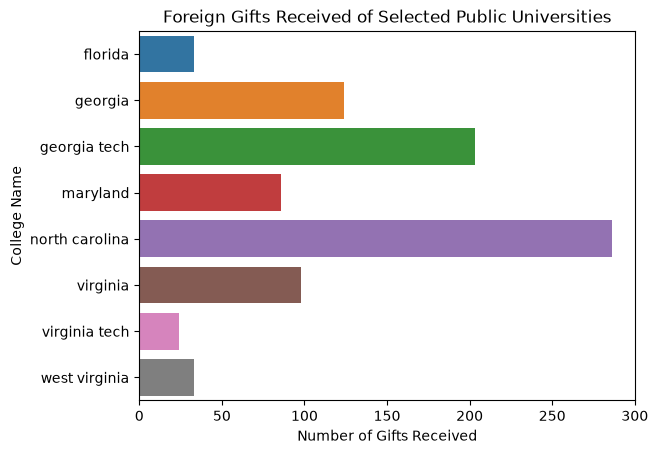

In [180]:
sns.barplot(gift_counts, x='Foreign Gift Amount', y='College Name', hue='College Name')

plt.xlabel('Number of Gifts Received')
plt.title('Foreign Gifts Received of Selected Public Universities')
plt.show()

In [181]:
gift_totals = college_data.groupby('College Name')['Foreign Gift Amount'].sum().reset_index()
gift_totals

,College Name,Foreign Gift Amount
0,florida,24759139
1,georgia,17797759
2,georgia tech,77979361
3,maryland,29933278
4,north carolina,41292544
5,virginia,22189238
6,virginia tech,11792062
7,west virginia,18509865


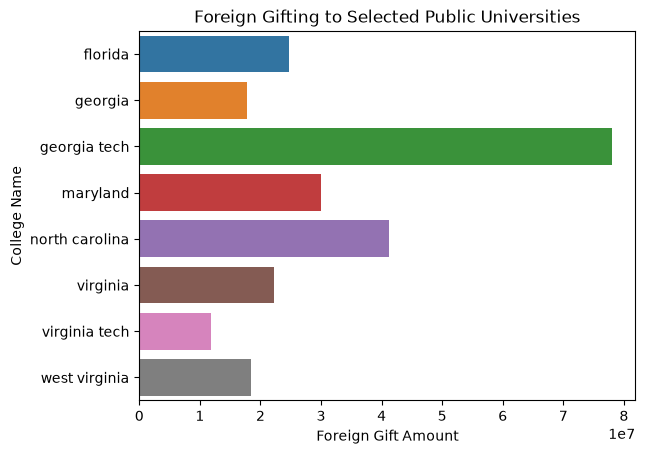

In [182]:
sns.barplot(gift_totals, x='Foreign Gift Amount', y='College Name', hue='College Name')

plt.title('Foreign Gifting to Selected Public Universities')
plt.show()

UVA sits about middle of the pack among these universities, with Georgia Tech making the most money by far.

In [183]:
top_countries = (
    college_data.groupby('Country of Giftor')['Foreign Gift Amount']
                .sum()
                .nlargest(6)
                .reset_index()
)
top_countries

,Country of Giftor,Foreign Gift Amount
0,SAUDI ARABIA,31213826
1,CANADA,20677632
2,ENGLAND,18035724
3,CHINA,17928767
4,KOREA,17552773
5,FRANCE,17173334


In [184]:
country_data = college_data[college_data['Country of Giftor'].isin(top_countries['Country of Giftor'])].copy()
country_data

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name,College Name
11252,11253,153500,University of Florida,Gainesville,FL,43466,2277135,Contract,SAUDI ARABIA,Royal Embassy of Saudi Arabia,florida
11257,11258,153500,University of Florida,Gainesville,FL,43490,1316105,Contract,CANADA,Intl Development Research Centre,florida
11264,11265,153500,University of Florida,Gainesville,FL,43522,311300,Contract,FRANCE,ORG FOR ECON CO-OPERATION AND DEVEL,florida
11265,11266,153500,University of Florida,Gainesville,FL,43522,311300,Contract,FRANCE,Org for Econ Cooperation and Develo,florida
11270,11271,153500,University of Florida,Gainesville,FL,43571,590789,Contract,KOREA,INST FOR INFORMATION & COMM TECH PR,florida
...,...,...,...,...,...,...,...,...,...,...,...
26801,26802,382700,West Virginia University,Morgantown,WV,43811,30000,Contract,CHINA,"Hanban, China",west virginia
26802,26803,382700,West Virginia University,Morgantown,WV,43815,926099,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia
26803,26804,382700,West Virginia University,Morgantown,WV,43815,951868,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia
26804,26805,382700,West Virginia University,Morgantown,WV,43815,313475,Contract,SAUDI ARABIA,Saudi Arabia Cultural Mission,west virginia


In [185]:
gift_millions = (country_data['Foreign Gift Amount']/(10**6)).round(2)

ct = pd.crosstab(country_data['College Name'], country_data['Country of Giftor'],
                 values=gift_millions, aggfunc='sum').fillna(0)

ct

Country of Giftor,CANADA,CHINA,ENGLAND,FRANCE,KOREA,SAUDI ARABIA
College Name,,,,,,
florida,1.90,0.00,0.00,1.02,1.96,2.74
georgia,0.56,0.00,2.67,7.98,0.00,0.39
georgia tech,3.00,13.98,5.58,3.28,10.93,20.80
maryland,0.59,1.28,2.39,1.63,3.43,0.40
north carolina,14.01,0.68,2.83,2.63,0.37,0.00
virginia,0.00,0.00,1.96,0.25,0.86,0.00
virginia tech,0.59,0.98,2.59,0.38,0.00,0.00
west virginia,0.00,1.03,0.00,0.00,0.00,6.83


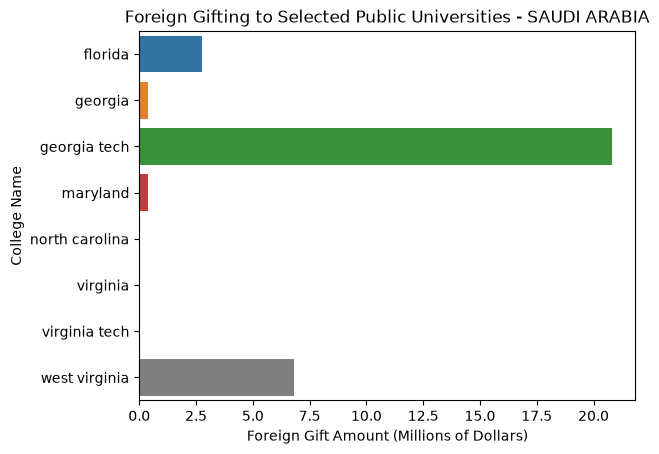

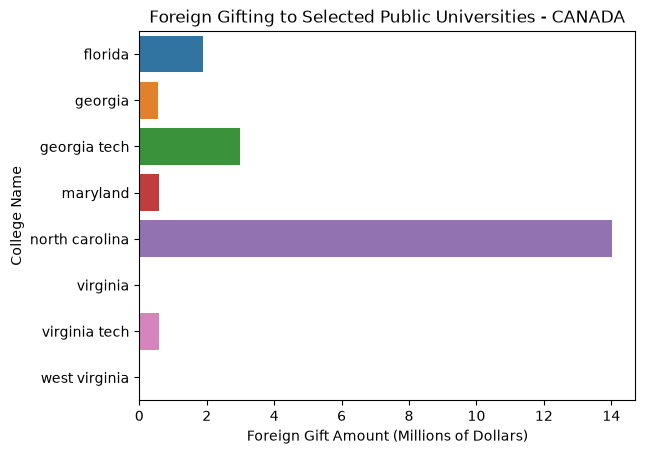

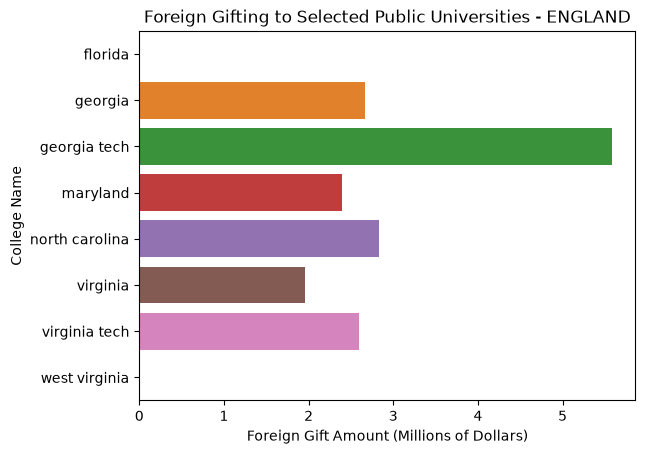

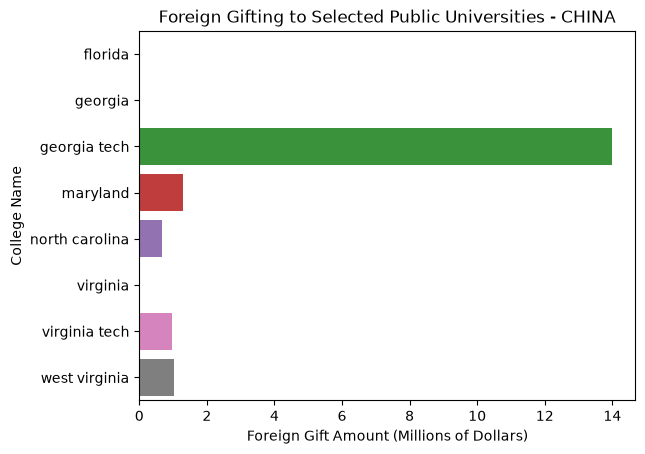

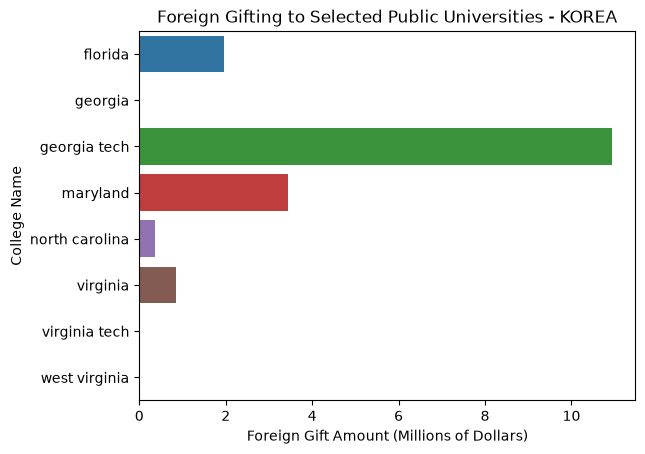

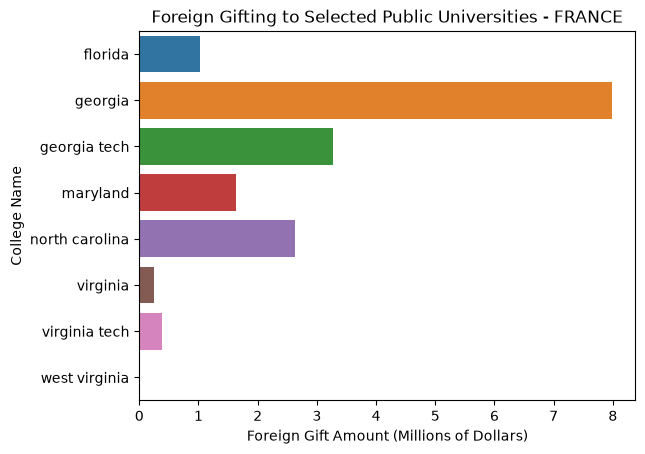

In [186]:
for ctry in top_countries['Country of Giftor']:
    sns.barplot(ct, x=ctry, y='College Name', hue='College Name')
    plt.xlabel('Foreign Gift Amount (Millions of Dollars)')
    plt.title(f'Foreign Gifting to Selected Public Universities - {ctry}')
    plt.show()

UVA makes considerably less from the top spending countries than other schools. UVA receives no money from Saudi Arabia, Canada, or China, and relatively little from the others. Georgia Tech and Maryland earn more than UVA from every country on this list.

# Market Comparison

In [204]:
gift_counts = df.groupby('Institution Name')['Foreign Gift Amount'].count()

print(f'UVA gifts received: {gift_counts['University of Virginia']}')
print(f'Median gifts received: {gift_counts.median()}')
print(f'Average gifts received: {gift_counts.mean():.2f}')

UVA gifts received: 98
Median gifts received: 12.0
Average gifts received: 88.75


In [205]:
gift_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()

print(f'UVA amount received (millions): {gift_totals['University of Virginia']/(10**6):.2f}')
print(f'Median amount received (millions): {gift_totals.median()/(10**6):.2f}')
print(f'Average amount received (millions): {gift_totals.mean()/(10**6):.2f}')

UVA amount received (millions): 22.19
Median amount received (millions): 6.49
Average amount received (millions): 52.20


While UVA makes near or below the mean in both number and sum of gifts, they make significantly more than the median of both groups. We saw in `initial_analysis.ipynb` that the means are heavily skewed by the highest earners.

# Analysis

UVA should maintain their connection with **Bangladesh**.

UVA needs to earn more from the top-donating countries, especially **Canada**, **China**, and **Saudi Arabia**. These countries dish out millions of dollars to public universities, but UVA has not received any of it.

Let's say UVA is hesitant to take money from foreign countries which the US does not have good relations with. Even still, other similar public universities are making more money from **Canada**, **England**, and **France**.

Georgia Tech, Georgia, Florida, Maryland, and North Carolina have all been given over $1M by France, while UVA has only made **$250,000.**

In [231]:
college_data[
    (college_data['Country of Giftor'].isin(['QATAR', 'SAUDI ARABIA', 'CHINA', 'CANADA']))
].groupby('College Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

College Name
georgia tech      38049050
north carolina    14969700
west virginia      7859930
florida            4632206
maryland           2851288
virginia tech      1567065
georgia             996446
Name: Foreign Gift Amount, dtype: int64